In [1]:
import pandas as pd
import os
import numpy as np
import json 

annotated_comments_dir = 'VideosComments/youtube/annotated_comments/{newspaper}'
annotated_metadata_dir = 'VideosComments/youtube/annotated_metadata/{newspaper}'

newspapers = ["corriere_della_sera", "repubblica", "lastampa", "ilmessaggero", "il_gazzettino"]

all_comments_gold = []
for newspaper in newspapers:
    newspaper_comments_dir = annotated_comments_dir.format(newspaper=newspaper)
    newspaper_metadata_dir = annotated_metadata_dir.format(newspaper=newspaper)

    # Find files with matching ids in both directories and keep only those with _gold at the end
    comment_files = set(f for f in os.listdir(newspaper_comments_dir) if f.endswith('_gold.csv'))
    metadata_files = set(f for f in os.listdir(newspaper_metadata_dir) if f.endswith('_gold.json'))
    matching_ids = set(f.split('_gold')[0] for f in comment_files) & set(f.split('_gold')[0] for f in metadata_files)
    assert len(matching_ids) == len(comment_files) == len(metadata_files), f"Mismatch in number of files for {newspaper}"

    # Concatenate into a single DataFrame with text, label, newspaper, topic columns
    for id in matching_ids:
        comment_file = os.path.join(newspaper_comments_dir, f"{id}_gold.csv")
        metadata_file = os.path.join(newspaper_metadata_dir, f"{id}_gold.json")

        # Read the comment CSV file
        comments_df = pd.read_csv(comment_file)
        comments_df['newspaper'] = newspaper  # Add newspaper column

        # Read the metadata JSON file
        with open(metadata_file, 'r') as f:
            metadata_json = json.load(f)
        topic = metadata_json['topic']  # Assuming topic is a single value in the JSON
        comments_df['topic'] = topic  # Add topic column

        all_comments_gold.append(comments_df)

all_comments_silver = []
for newspaper in newspapers:
    newspaper_comments_dir = annotated_comments_dir.format(newspaper=newspaper)
    newspaper_metadata_dir = annotated_metadata_dir.format(newspaper=newspaper)

    # Find files with matching ids in both directories and keep only those with _silver at the end
    comment_files = set(f for f in os.listdir(newspaper_comments_dir) if f.endswith('_silver.csv'))
    metadata_files = set(f for f in os.listdir(newspaper_metadata_dir) if f.endswith('_silver.json'))
    matching_ids = set(f.split('_silver')[0] for f in comment_files) & set(f.split('_silver')[0] for f in metadata_files)
    assert len(matching_ids) == len(comment_files) == len(metadata_files), f"Mismatch in number of files for {newspaper}"

    # Concatenate into a single DataFrame with text, label, newspaper, topic columns
    for id in matching_ids:
        comment_file = os.path.join(newspaper_comments_dir, f"{id}_silver.csv")
        metadata_file = os.path.join(newspaper_metadata_dir, f"{id}_silver.json")

        # Read the comment CSV file
        comments_df = pd.read_csv(comment_file)
        comments_df['newspaper'] = newspaper  # Add newspaper column

        # Read the metadata JSON file
        with open(metadata_file, 'r') as f:
            metadata_json = json.load(f)
        topic = metadata_json['topic']  # Assuming topic is a single value in the JSON
        comments_df['topic'] = topic  # Add topic column

        all_comments_silver.append(comments_df)

,comment_id,parent_comment_id,video_id,is_reply,author,published_at,updated_at,like_count,text,inferred_parent_id,depth,newspaper,author_anon,label,topic
0,UgzZI8TfZlE8AnWQ6MJ4AaABAg,NaN,RlKqohuIcfc,False,@brunellabrianzi6452,2026-05-19T12:45:17Z,2026-05-19T12:45:17Z,0,"Sembra che abbiano azzardato troppo, sarebbe ...",NaN,0.0,corriere_della_sera,author_4060,0,"disaster, accident and emergency incident"
1,UgxMnhx9K35CIa_L5Wd4AaABAg,NaN,RIdMlHkZj2o,False,@SIMPLYDAW,2026-05-18T16:55:16Z,2026-05-18T16:55:16Z,10,"Basta con queste giustificazioni , troppo spes...",NaN,0.0,corriere_della_sera,author_4138,1,politics and government
2,Ugx_MOb3bumKDGAAZGR4AaABAg,NaN,RIdMlHkZj2o,False,@sergiopetruzzi101,2026-05-18T17:14:25Z,2026-05-18T17:14:25Z,7,"Anche piandedosi si e' bevuto il cervello ,gio...",NaN,0.0,corriere_della_sera,author_723,1,politics and government
3,UgzLKfdilW-tEjltPaB4AaABAg,NaN,RIdMlHkZj2o,False,@massimilianomonino9567,2026-05-18T17:47:03Z,2026-05-18T17:47:03Z,5,Maledetti politici... passerà per disagiato e ...,NaN,0.0,corriere_della_sera,author_4139,1,politics and government
4,UgzLKfdilW-tEjltPaB4AaABAg.AWxnSjH6egGAWxzMVYMuYL,UgzLKfdilW-tEjltPaB4AaABAg,RIdMlHkZj2o,True,@citikane59,2026-05-18T19:31:04Z,2026-05-18T19:31:04Z,0,"Bastava dargli un lavoro vicino a casa, come a...",UgzLKfdilW-tEjltPaB4AaABAg,1.0,corriere_della_sera,author_4140,0,politics and government
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13431,UgwY-aK_b7T2YXQswVt4AaABAg,NaN,pSKv_OPoWUs,False,@daryg352,2026-05-17T10:23:04Z,2026-05-17T10:23:04Z,3,Il lusso è un diritto ma non è per tutti. Solo...,NaN,0.0,il_gazzettino,author_6759,0,"crime, law and justice"
13432,UgzlqSitheaRboO1qgx4AaABAg,NaN,pSKv_OPoWUs,False,@moreno9622,2026-05-17T10:58:41Z,2026-05-17T10:58:41Z,5,Andranno da Landini a protestare 😂😂😂😂,NaN,0.0,il_gazzettino,author_709,1,"crime, law and justice"
13433,UgwZ6mFfpJbAg76Yxtp4AaABAg,NaN,pSKv_OPoWUs,False,@andreamancini-g3g,2026-05-18T17:26:46Z,2026-05-18T17:26:46Z,0,bruciate i campi room,NaN,0.0,il_gazzettino,author_120,1,"crime, law and justice"
13434,UgzllVsQ8ok1HHNyhMR4AaABAg,NaN,pSKv_OPoWUs,False,@frac8383,2026-05-19T12:30:27Z,2026-05-19T12:30:27Z,0,Strano,NaN,0.0,il_gazzettino,author_2864,0,"crime, law and justice"


In [2]:
all_comments_gold_df = pd.concat(all_comments_gold, ignore_index=True)
print(f"Length of all comments: {len(all_comments_gold_df)}")

all_comments_silver_df = pd.concat(all_comments_silver, ignore_index=True)
print(f"Length of all comments: {len(all_comments_silver_df)}")

Length of all comments: 776
Length of all comments: 13436


In [4]:
sum(all_comments_gold_df['label']) / len(all_comments_gold_df)
for newspaper in newspapers:
    print(f"Percentage of offensive comments for that newspaper: {newspaper}")
    print(f"Number of comments for that newspaper: {len(all_comments_gold_df[all_comments_gold_df['newspaper'] == newspaper])}")
    newspaper_df = all_comments_gold_df[all_comments_gold_df['newspaper'] == newspaper]
    print(round(sum(newspaper_df['label']) / len(newspaper_df) * 100, 3)) 

Percentage of offensive comments for that newspaper: corriere_della_sera
Number of comments for that newspaper: 177
18.644
Percentage of offensive comments for that newspaper: repubblica
Number of comments for that newspaper: 176
35.227
Percentage of offensive comments for that newspaper: lastampa
Number of comments for that newspaper: 85
36.471
Percentage of offensive comments for that newspaper: ilmessaggero
Number of comments for that newspaper: 169
17.16
Percentage of offensive comments for that newspaper: il_gazzettino
Number of comments for that newspaper: 169
44.379


In [5]:
sum(all_comments_silver_df['label']) / len(all_comments_silver_df)
for newspaper in newspapers:
    print(f"Percentage of offensive comments for that newspaper: {newspaper}")
    print(f"Number of comments for that newspaper: {len(all_comments_silver_df[all_comments_silver_df['newspaper'] == newspaper])}")
    newspaper_df = all_comments_silver_df[all_comments_silver_df['newspaper'] == newspaper]
    print(round(sum(newspaper_df['label']) / len(newspaper_df) * 100, 3)) 

Percentage of offensive comments for that newspaper: corriere_della_sera
Number of comments for that newspaper: 1922
63.267
Percentage of offensive comments for that newspaper: repubblica
Number of comments for that newspaper: 6303
63.589
Percentage of offensive comments for that newspaper: lastampa
Number of comments for that newspaper: 947
45.301
Percentage of offensive comments for that newspaper: ilmessaggero
Number of comments for that newspaper: 3708
60.68
Percentage of offensive comments for that newspaper: il_gazzettino
Number of comments for that newspaper: 556
51.799


- - - 
Visualizations at comment level

In [6]:
all_comments_df = pd.concat(
    [all_comments_gold_df, all_comments_silver_df],
    ignore_index=True
)

def compute_stats(df):
    overall_off = df["label"].mean() * 100
    overall_n = len(df)

    topic_stats = (
        df.groupby("topic")
        .agg(
            offensive=("label", lambda x: x.mean() * 100),
            n=("label", "size")
        )
    )

    stats = pd.concat([
        pd.DataFrame(
            {"offensive": [overall_off], "n": [overall_n]},
            index=["Total"]
        ),
        topic_stats
    ])

    stats["non_offensive"] = 100 - stats["offensive"]
    return stats


total_stats = compute_stats(all_comments_df)
gold_stats = compute_stats(all_comments_gold_df)
silver_stats = compute_stats(all_comments_silver_df)

# union of all categories
topics = ["Total"] + sorted(
    (
        set(total_stats.index)
        | set(gold_stats.index)
        | set(silver_stats.index)
    ) - {"Total"}
)

total_stats = total_stats.reindex(topics)
gold_stats = gold_stats.reindex(topics)
silver_stats = silver_stats.reindex(topics)

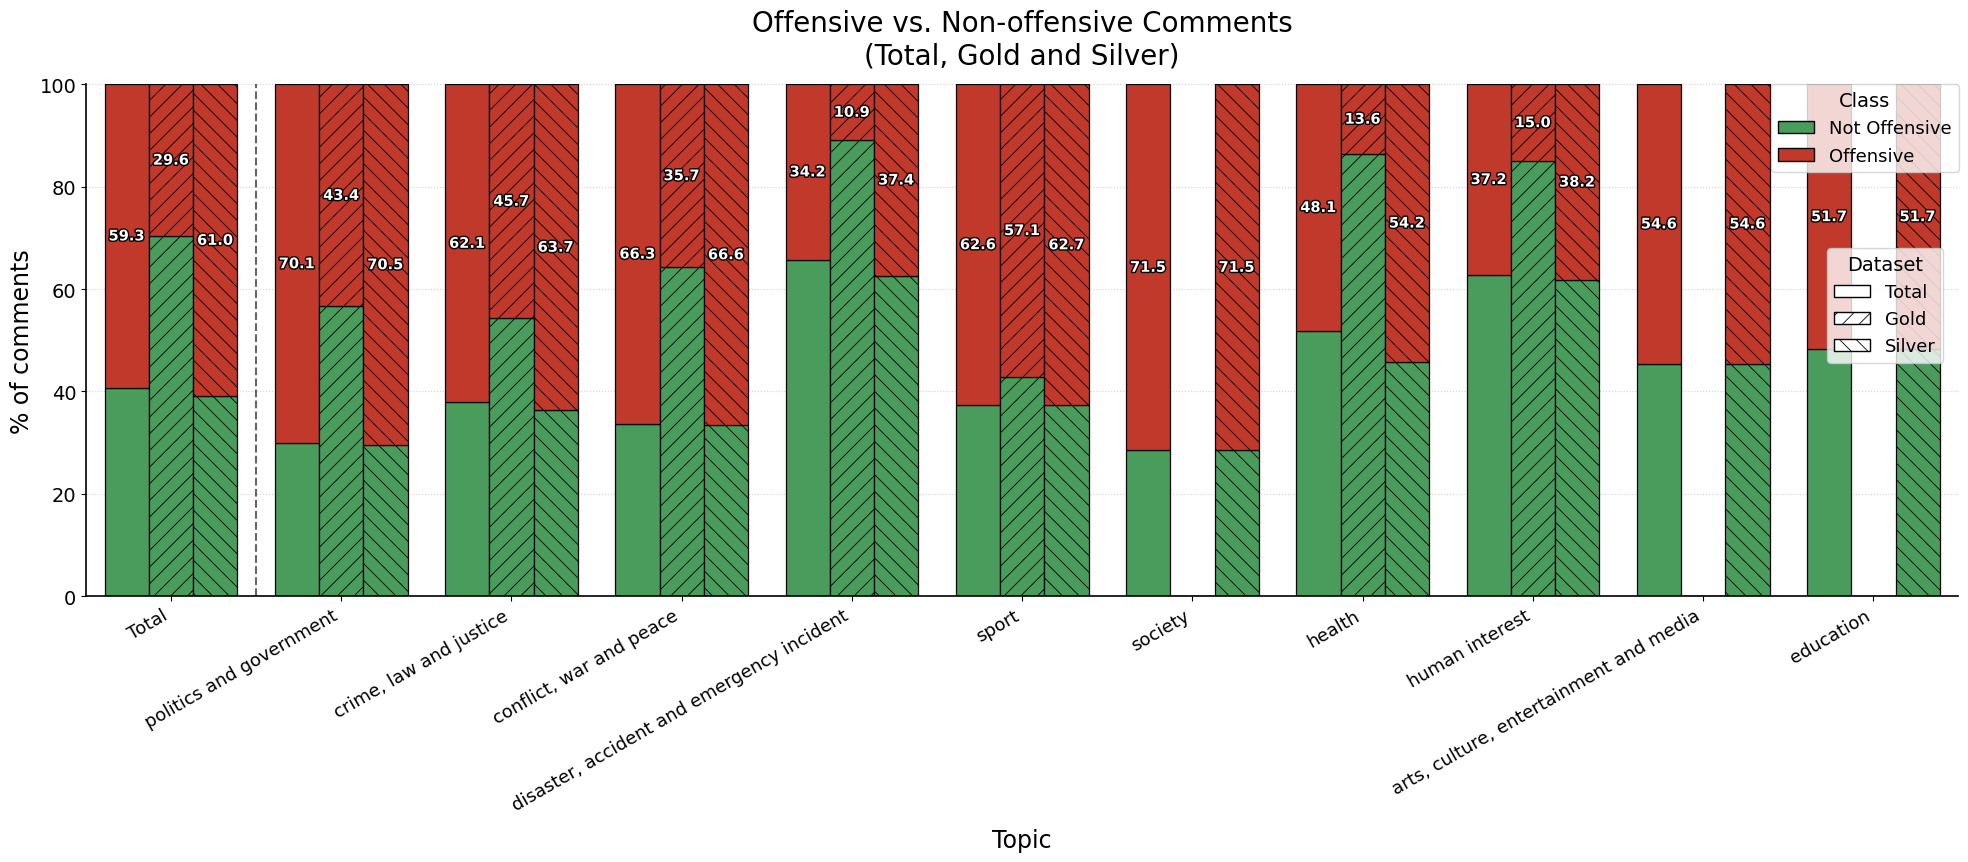

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Patch



# ----------------------------------------------------------------------
# Global style
# ----------------------------------------------------------------------
plt.rcParams.update({
    "font.size":             15,
    "axes.titlesize":        20,
    "axes.labelsize":        17,
    "xtick.labelsize":       13,
    "ytick.labelsize":       14,
    "legend.fontsize":       13,
    "legend.title_fontsize": 14,
    "axes.linewidth":        1.2,
    "hatch.linewidth":       0.6,        # <-- thinner, less noisy hatching
    "font.family":           "DejaVu Sans",
})

# Muted but clear palette (swap if you want)
COLOR_NON = "#4a9c5d"   # green  = non-offensive
COLOR_OFF = "#c0392b"   # red    = offensive

DROP_INCOMPLETE = False   # set True to hide topics missing Gold/Silver

# ----------------------------------------------------------------------
# Data prep
# ----------------------------------------------------------------------
top_topics = (
    all_comments_df["topic"]
    .value_counts()
    .head(10)
    .index
    .tolist()
)
topics = ["Total"] + top_topics

total_plot  = total_stats.reindex(topics)
gold_plot   = gold_stats.reindex(topics)
silver_plot = silver_stats.reindex(topics)

if DROP_INCOMPLETE:
    complete = [
        t for t in topics
        if pd.notna(gold_plot.loc[t, "offensive"])
        and pd.notna(silver_plot.loc[t, "offensive"])
    ]
    topics = complete
    total_plot, gold_plot, silver_plot = (
        d.reindex(topics) for d in (total_plot, gold_plot, silver_plot)
    )

# ----------------------------------------------------------------------
# Figure
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(18, 8))

width = 0.26
x = np.arange(len(topics))

datasets = [
    ("Total",  total_plot,  -width),
    ("Gold",   gold_plot,    0.0),
    ("Silver", silver_plot,  width),
]
hatches = {"Total": "", "Gold": "//", "Silver": "\\\\"}

label_fx = [pe.withStroke(linewidth=2.0, foreground="black")]

for name, stats, offset in datasets:
    non_off = stats["non_offensive"].fillna(0)
    off     = stats["offensive"].fillna(0)

    ax.bar(x + offset, non_off, width=width,
           color=COLOR_NON, edgecolor="black", linewidth=0.9,
           hatch=hatches[name])
    ax.bar(x + offset, off, width=width, bottom=non_off,
           color=COLOR_OFF, edgecolor="black", linewidth=0.9,
           hatch=hatches[name])

    # Offensive % label, centered in the red segment (skip tiny segments)
    for i, val in enumerate(stats["offensive"]):
        if pd.notna(val) and val >= 4:
            ax.text(
                x[i] + offset, non_off.iloc[i] + val / 2,
                f"{val:.1f}",
                ha="center", va="center",
                color="white", fontsize=10.5, fontweight="bold",
                path_effects=label_fx,
            )

# Separator after "Total"
ax.axvline(x=0.5, color="black", linestyle="--", linewidth=1.5, alpha=0.6)

# ----------------------------------------------------------------------
# Axes cosmetics
# ----------------------------------------------------------------------
ax.set_xticks(x)
ax.set_xticklabels(topics, rotation=30, ha="right")
ax.set_ylim(0, 100)
ax.set_yticks(np.arange(0, 101, 20))
ax.set_ylabel("% of comments")
ax.set_xlabel("Topic", labelpad=10)
ax.set_title("Offensive vs. Non-offensive Comments\n(Total, Gold and Silver)", pad=15)

ax.yaxis.grid(True, linestyle=":", linewidth=0.8, alpha=0.55)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.margins(x=0.01)

# ----------------------------------------------------------------------
# Two legends (color = class, hatch = dataset)
# ----------------------------------------------------------------------
class_handles = [
    Patch(facecolor=COLOR_NON, edgecolor="black", label="Not Offensive"),
    Patch(facecolor=COLOR_OFF, edgecolor="black", label="Offensive"),
]
dataset_handles = [
    Patch(facecolor="white", edgecolor="black", hatch=hatches[n], label=n)
    for n in ("Total", "Gold", "Silver")
]

leg1 = ax.legend(handles=class_handles, title="Class",
                 loc="upper left", bbox_to_anchor=(0.90, 1.00),
                 frameon=True, borderaxespad=0.0)
ax.add_artist(leg1)
ax.legend(handles=dataset_handles, title="Dataset",
          loc="upper left", bbox_to_anchor=(0.93, 0.68),
          frameon=True, borderaxespad=0.0)

# Reserve margins manually (DON'T use tight_layout with outside legends)
# fig.subplots_adjust(left=0.06, right=0.83, top=0.90, bottom=0.26)
fig.subplots_adjust(left=0.06, right=1.1, top=0.90, bottom=0.26)

fig.savefig("offensive_by_topic.pdf", bbox_inches="tight")          # vector, for LaTeX
fig.savefig("offensive_by_topic.png", bbox_inches="tight", dpi=300) # raster fallback
plt.show()

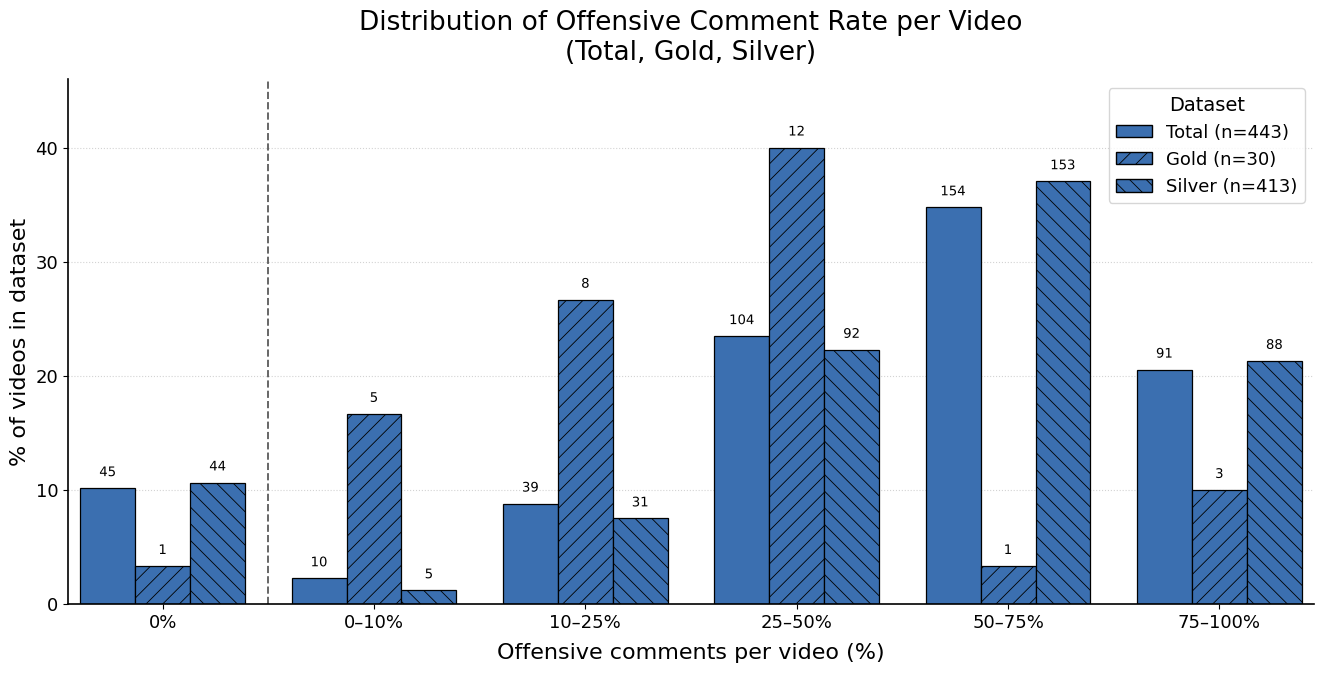

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Patch

# ----------------------------------------------------------------------
# Style
# ----------------------------------------------------------------------
plt.rcParams.update({
    "font.size":             14,
    "axes.titlesize":        19,
    "axes.labelsize":        16,
    "xtick.labelsize":       13,
    "ytick.labelsize":       13,
    "legend.fontsize":       13,
    "legend.title_fontsize": 14,
    "axes.linewidth":        1.2,
    "hatch.linewidth":       0.6,
    "font.family":           "DejaVu Sans",
})
COLOR = "#3b6fb0"   # one blue for all three; dataset encoded by hatch

# ----------------------------------------------------------------------
# Distribution helper  ->  returns RAW counts
# ----------------------------------------------------------------------
def get_video_distribution(df):
    off_rate = df.groupby("video_id")["label"].mean() * 100
    counts = {"0%": int((off_rate == 0).sum())}
    positive = off_rate[off_rate > 0]
    bins = [
        ("0–10%",   0.0001, 10),
        ("10–25%",  10, 25),
        ("25–50%",  25, 50),
        ("50–75%",  50, 75),
        ("75–100%", 75, 100),
    ]
    for label, low, high in bins:
        counts[label] = int(((positive > low) & (positive <= high)).sum())
    return pd.Series(counts)

all_comments_df = pd.concat(
    [all_comments_gold_df, all_comments_silver_df], ignore_index=True
)

dists = {
    "Total":  get_video_distribution(all_comments_df),
    "Gold":   get_video_distribution(all_comments_gold_df),
    "Silver": get_video_distribution(all_comments_silver_df),
}
totals = {name: d.sum() for name, d in dists.items()}      # N videos per dataset
pct = {name: d / totals[name] * 100 for name, d in dists.items()}  # normalized

# ----------------------------------------------------------------------
# Figure
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 7))

bins = list(dists["Total"].index)
x = np.arange(len(bins))
width = 0.26
hatches = {"Total": "", "Gold": "//", "Silver": "\\\\"}
offsets = {"Total": -width, "Gold": 0.0, "Silver": width}
label_fx = [pe.withStroke(linewidth=1.8, foreground="white")]

for name in ("Total", "Gold", "Silver"):
    bars = ax.bar(
        x + offsets[name], pct[name].values, width=width,
        color=COLOR, edgecolor="black", linewidth=0.9, hatch=hatches[name],
    )
    # annotate with RAW count (n) so absolute numbers aren't lost
    for rect, raw in zip(bars, dists[name].values):
        if rect.get_height() > 0:
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_height() + 0.8,
                f"{raw}",
                ha="center", va="bottom", fontsize=9.5,
                path_effects=label_fx,
            )

# Separator after 0%
ax.axvline(x=0.5, linestyle="--", color="black", linewidth=1.4, alpha=0.6)

ax.set_xticks(x)
ax.set_xticklabels(bins)
ax.set_xlabel("Offensive comments per video (%)", labelpad=8)
ax.set_ylabel("% of videos in dataset")
ax.set_title("Distribution of Offensive Comment Rate per Video\n(Total, Gold, Silver)", pad=14)

ax.set_ylim(0, max(max(p.values) for p in pct.values()) * 1.15)
ax.yaxis.grid(True, linestyle=":", linewidth=0.8, alpha=0.55)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.margins(x=0.01)

# Legend shows N per dataset
dataset_handles = [
    Patch(facecolor=COLOR, edgecolor="black", hatch=hatches[n],
          label=f"{n} (n={totals[n]})")
    for n in ("Total", "Gold", "Silver")
]
ax.legend(handles=dataset_handles, title="Dataset",
          loc="upper right", frameon=True)

fig.subplots_adjust(left=0.08, right=0.97, top=0.88, bottom=0.13)
fig.savefig("video_offrate_dist.pdf", bbox_inches="tight")
fig.savefig("video_offrate_dist.png", bbox_inches="tight", dpi=300)
plt.show()

- - - 
### Visualizations of the metric
Careful cause entries w.o. comments are not visualized here.

In [27]:
# Group by video id and newspaper and topic, count total comments and offensive comments
grouped_gold = all_comments_gold_df.groupby(['video_id', 'newspaper', 'topic']).agg(
    n=('text', 'count'),
    n_off=('label', lambda x: (x == 1).sum())
).reset_index()

In [28]:
# Group by video id and newspaper and topic, count total comments and offensive comments
grouped_silver = all_comments_silver_df.groupby(['video_id', 'newspaper', 'topic']).agg(
    n=('text', 'count'),
    n_off=('label', lambda x: (x == 1).sum())
).reset_index()

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def offensive_score(n, n_off, lambda1=1.0):
    if n == 0:
        return 0.0
    if n_off == 0:
        return 0.0
    return np.arctan((n_off / n) + lambda1 * np.log(n_off)) / (np.pi / 2)


In [45]:
grouped_gold['offensive_score'] = grouped_gold.apply(lambda row: offensive_score(row['n'], row['n_off'], 1.0), axis=1)
grouped_silver['offensive_score'] = grouped_silver.apply(lambda row: offensive_score(row['n'], row['n_off'], 1.0), axis=1)

In [46]:
grouped_gold['dataset'] = 'gold'
grouped_silver['dataset'] = 'silver'
grouped_total = pd.concat([grouped_gold, grouped_silver])

In [47]:
grouped_total

,video_id,newspaper,topic,n,n_off,offensive_score,dataset
0,-Jz16gcNDG4,corriere_della_sera,human interest,20,3,0.570102,gold
1,0paspwjsZmE,ilmessaggero,weather,29,8,0.744391,gold
2,4cvfxPJACdc,repubblica,environment,33,13,0.792517,gold
3,5s85hZ-6qzw,il_gazzettino,"crime, law and justice",38,10,0.763407,gold
4,7FfdwuricJk,repubblica,"crime, law and justice",29,14,0.802649,gold
...,...,...,...,...,...,...,...
408,zO2XylesnrE,repubblica,politics and government,120,61,0.864274,silver
409,zR7WKsrl4to,corriere_della_sera,"disaster, accident and emergency incident",13,8,0.773789,silver
410,zSDdaX_apcQ,repubblica,lifestyle and leisure,7,1,0.090334,silver
411,zfMn9NDUffM,repubblica,weather,24,12,0.794202,silver


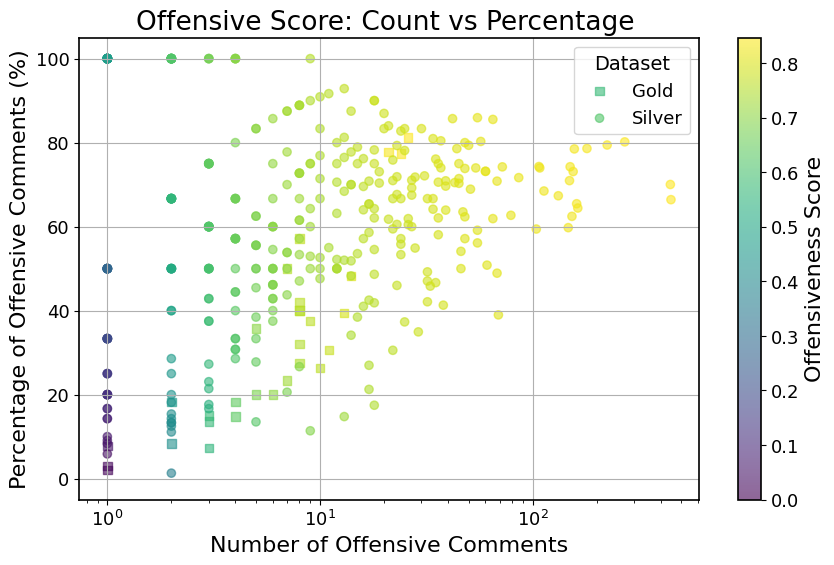

In [48]:
import matplotlib.pyplot as plt

# Compute percentage of offensive comments
grouped_total['offensive_pct'] = (grouped_total['n_off'] / grouped_total['n']) * 100

plt.figure(figsize=(10, 6))

# Gold = square
gold = grouped_total[grouped_total['dataset'] == 'gold']
sc_gold = plt.scatter(
    gold['n_off'],
    gold['offensive_pct'],
    c=gold['offensive_score'],
    cmap='viridis',
    alpha=0.6,
    marker='s',   # square
    label='Gold'
)

# Silver = circle
silver = grouped_total[grouped_total['dataset'] == 'silver']
sc_silver = plt.scatter(
    silver['n_off'],
    silver['offensive_pct'],
    c=silver['offensive_score'],
    cmap='viridis',
    alpha=0.6,
    marker='o',   # circle
    label='Silver'
)
# log x-axis
plt.xscale('log')
plt.xlabel('Number of Offensive Comments')
plt.ylabel('Percentage of Offensive Comments (%)')
plt.title('Offensive Score: Count vs Percentage ')


# Colorbar (both scatters use the same colormap)
plt.colorbar(sc_gold, label='Offensiveness Score')

plt.legend(title='Dataset')
plt.grid(True)
plt.savefig("offensive_score.png", bbox_inches="tight", dpi=300) # raster fallback
plt.show()

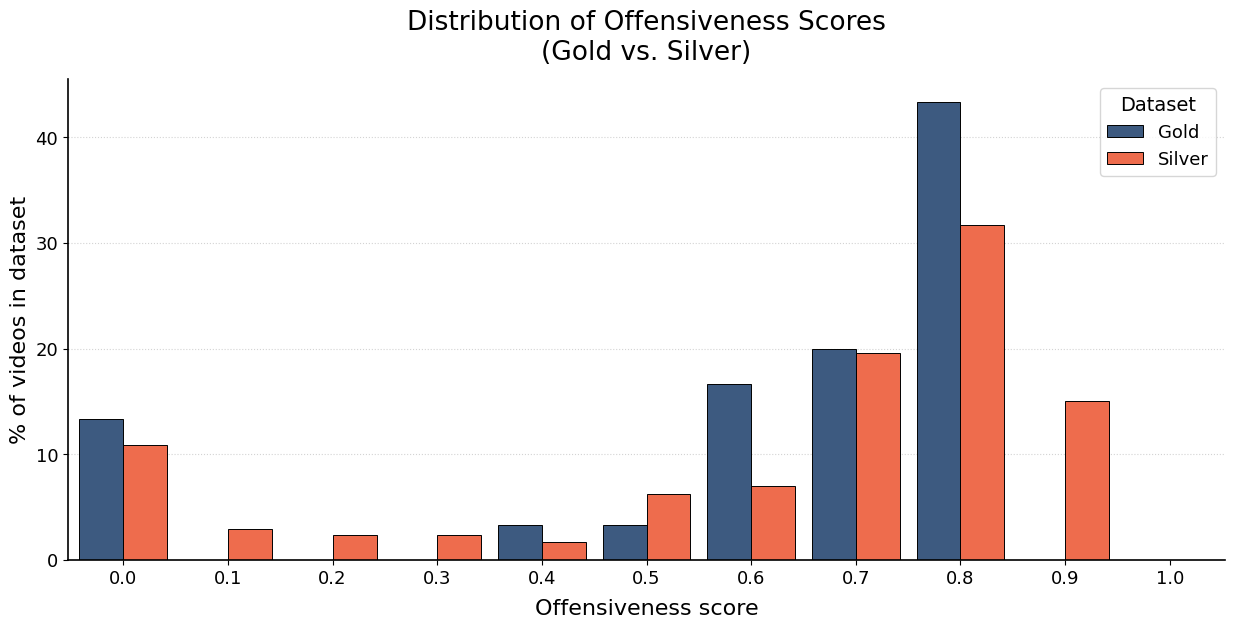

In [52]:
import numpy as np
import matplotlib.pyplot as plt
# ----------------------------------------------------------------------
# Style
# ----------------------------------------------------------------------
plt.rcParams.update({
    "font.size":             14,
    "axes.titlesize":        19,
    "axes.labelsize":        16,
    "xtick.labelsize":       13,
    "ytick.labelsize":       13,
    "legend.fontsize":       13,
    "legend.title_fontsize": 14,
    "axes.linewidth":        1.2,
    "font.family":           "DejaVu Sans",
})
COLOR_GOLD   = "#3D5A80"   # slate blue   (the "Gold" dataset)
COLOR_SILVER = "#EE6C4D"   # warm coral   (the "Silver" dataset)
# ----------------------------------------------------------------------
# Fixed bins centered on 0.0, 0.1, 0.2, ... 1.0
# ----------------------------------------------------------------------
gold   = grouped_gold['offensive_score'].dropna().values
silver = grouped_silver['offensive_score'].dropna().values

levels = np.round(np.arange(0.0, 1.01, 0.1), 1)        # 0.0 ... 1.0  (11 values)
edges  = np.concatenate(([-0.05], levels[:-1] + 0.05, [1.05]))  # bin boundaries that center on each level

# Counts -> % of videos WITHIN each dataset
gold_pct   = np.histogram(gold,   bins=edges)[0] / len(gold)   * 100
silver_pct = np.histogram(silver, bins=edges)[0] / len(silver) * 100
# ----------------------------------------------------------------------
# Figure — dodged (side-by-side) bars at categorical positions
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 6.5))
x = np.arange(len(levels))   # 0, 1, 2, ... 10  (evenly spaced)
w = 0.42                     # each bar slightly under half a slot so the pair fits

ax.bar(x - w/2, gold_pct,   width=w, color=COLOR_GOLD,
       edgecolor="black", linewidth=0.7, label="Gold")
ax.bar(x + w/2, silver_pct, width=w, color=COLOR_SILVER,
       edgecolor="black", linewidth=0.7, label="Silver")

ax.set_xlabel("Offensiveness score", labelpad=8)
ax.set_ylabel("% of videos in dataset")
ax.set_title("Distribution of Offensiveness Scores\n(Gold vs. Silver)", pad=14)

# aligned ticks: one tick per level, centered under each bar pair
ax.set_xticks(x)
ax.set_xticklabels([f"{lvl:.1f}" for lvl in levels])

ax.yaxis.grid(True, linestyle=":", linewidth=0.8, alpha=0.55)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.margins(x=0.01)
ax.legend(title="Dataset", frameon=True)
fig.subplots_adjust(left=0.08, right=0.97, top=0.87, bottom=0.13)
fig.savefig("offensive_score_dist.pdf", bbox_inches="tight")
fig.savefig("offensive_score_dist.png", bbox_inches="tight", dpi=300)
plt.show()